# Shock-finder dissipation at selected $t/t_{\rm fb}$

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import csv
from pathlib import Path

import numpy as np
import unyt as u

import dev
import matplotlib.pyplot as plt
import richio
from richio import shockfinder as sf

RESULT_ROOT = Path('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection')
ANALYSIS_ROOT = RESULT_ROOT / 'analysis'
CELL_ROOT = ANALYSIS_ROOT / 'per-cell'
FIGURE_ROOT = ANALYSIS_ROOT / 'figures'
for directory in (ANALYSIS_ROOT, CELL_ROOT, FIGURE_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

RUNS = ('1e4', '1e5', '1e6')
RUN_LABELS = {'1e4': r'$10^4\,M_\odot$', '1e5': r'$10^5\,M_\odot$', '1e6': r'$10^6\,M_\odot$'}
RUN_COLORS = {'1e4': 'C0', '1e5': 'C1', '1e6': 'C2'}
TDE = {
    '1e4': dict(Mbh=1e4 * u.Msun, Mstar=0.5 * u.Msun, Rstar=0.47 * u.Rsun),
    '1e5': dict(Mbh=1e5 * u.Msun, Mstar=0.5 * u.Msun, Rstar=0.47 * u.Rsun),
    '1e6': dict(Mbh=1e6 * u.Msun, Mstar=1.0 * u.Msun, Rstar=1.0 * u.Rsun),
}
for cfg in TDE.values():
    tde = dev.TDEBasics(**cfg, beta=1)
    cfg['r_p'] = tde.r_p.to_value('Rsun')
    cfg['r_a'] = tde.r_a.to_value('Rsun')
    cfg['t_fb_s'] = tde.t_fb.to_value('s')
    cfg['Delta_erg'] = (u.G * cfg['Mbh'] / (4 * tde.r_p) * cfg['Mstar'] / 2).to_value('erg')

result_paths = sorted(RESULT_ROOT.glob('1e*/shockfinder_snap_*.npz'))
assert len(result_paths) == 13, f'Expected 13 shock-finder results, found {len(result_paths)}'
result_paths

[PosixPath('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/1e4/shockfinder_snap_0054.npz'),
 PosixPath('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/1e4/shockfinder_snap_0077.npz'),
 PosixPath('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/1e4/shockfinder_snap_0108.npz'),
 PosixPath('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/1e4/shockfinder_snap_0140.npz'),
 PosixPath('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/1e4/shockfinder_snap_0151.npz'),
 PosixPath('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/1e5/shockfinder_snap_0103.npz'),
 PosixPath('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/1e5/shockfinder_snap_0142.npz'),
 PosixPath('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/1e5/shockfinder_snap_0161.npz'),
 PosixPath('/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/1e6/shockfinder_snap_0850.npz'),
 PosixPath('/home/hey4/rich_tde/data/processed

In [2]:
def scalar(data, key, cast=float):
    return cast(np.asarray(data[key]).item())


def extract_per_cell(result_path):
    with np.load(result_path) as result:
        run = scalar(result, 'run', str)
        snapnum = scalar(result, 'snapnum', int)
        snap_path = scalar(result, 'snap_path', str)
        surf_idx = result['surf_idx']
        pre_idx = result['pre_idx']
        mach_T = result['mach_T']
        metadata = {
            'run': run, 'snapnum': snapnum, 'snap_path': snap_path,
            'requested_tfb': scalar(result, 'requested_tfb'),
            'is_last': scalar(result, 'is_last', bool),
            'time_tfb': scalar(result, 'time_tfb'),
            'n_cells': scalar(result, 'n_cells', int),
            'n_candidates': scalar(result, 'n_candidates', int),
        }

    snap = richio.load(snap_path)
    P, rho, sie = snap.P, snap.rho, snap.sie
    c = np.sqrt((P / rho / sie + 1) * P / rho)
    rho_pre = rho[pre_idx]
    c_pre = c[pre_idx]
    V_sh = snap.volume[surf_idx]
    A_sh = np.pi**(1/3) * (3 * V_sh / 4)**(2/3)
    cell_power = (
        sf.delta(mach_T) * (0.5 * rho_pre * A_sh * c_pre**3) * mach_T**3
    ).to('erg/s')
    x = snap.X[surf_idx].to('Rsun')
    y = snap.Y[surf_idx].to('Rsun')
    z = snap.Z[surf_idx].to('Rsun')
    radius = np.sqrt(x**2 + y**2 + z**2)
    finite = np.isfinite(cell_power) & np.isfinite(radius) & (cell_power > 0)

    output_path = CELL_ROOT / f'{run}_shock_dissipation_snap_{snapnum:04d}.npz'
    np.savez_compressed(
        output_path, run=run, snapnum=snapnum, snap_path=snap_path,
        requested_tfb=metadata['requested_tfb'], is_last=metadata['is_last'],
        time_tfb=metadata['time_tfb'], surf_idx=surf_idx[finite],
        pre_idx=pre_idx[finite], mach_T=mach_T[finite],
        shock_power_erg_s=cell_power[finite].to_value(),
        x_Rsun=x[finite].to_value(), y_Rsun=y[finite].to_value(),
        z_Rsun=z[finite].to_value(), radius_Rsun=radius[finite].to_value(),
    )

    weights = cell_power[finite].to_value()
    radii = radius[finite].to_value()
    metadata.update({
        'n_surface': len(surf_idx), 'n_finite_positive': int(finite.sum()),
        'Ediss_erg_s': float(weights.sum()),
        'Rdiss_Rsun': float(np.average(radii, weights=weights)),
        'per_cell_path': str(output_path),
    })
    return metadata


summaries = [extract_per_cell(path) for path in result_paths]
summaries.sort(key=lambda row: (row['run'], row['time_tfb']))
len(summaries), summaries[0]

(13,
 {'run': '1e4',
  'snapnum': 54,
  'snap_path': '/data1/projects/pi-rossiem/TDE_data/NewSnellius/R0.47M0.5BH10000beta1S60ComptonHiRes/snap_full_54.h5',
  'requested_tfb': 0.5,
  'is_last': False,
  'time_tfb': 0.505271103633409,
  'n_cells': 39421950,
  'n_candidates': 5490222,
  'n_surface': 385677,
  'n_finite_positive': 385677,
  'Ediss_erg_s': 2.882510298611501e+39,
  'Rdiss_Rsun': 15.419384148079327,
  'per_cell_path': '/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/per-cell/1e4_shock_dissipation_snap_0054.npz'})

In [3]:
summary_path = ANALYSIS_ROOT / 'shockfinder_summary.csv'
columns = [
    'run', 'snapnum', 'requested_tfb', 'is_last', 'time_tfb', 'n_cells',
    'n_candidates', 'n_surface', 'n_finite_positive', 'Ediss_erg_s',
    'Rdiss_Rsun', 'snap_path', 'per_cell_path',
]
with summary_path.open('w', newline='') as stream:
    writer = csv.DictWriter(stream, fieldnames=columns)
    writer.writeheader()
    writer.writerows(summaries)
print(f'Saved {summary_path}')
for row in summaries:
    tag = 'last' if row['is_last'] else f"requested {row['requested_tfb']:.1f}"
    print(f"{row['run']} snap {row['snapnum']:4d}: t={row['time_tfb']:.3f} t_fb ({tag}), "
          f"N_sh={row['n_surface']:,}, Ediss={row['Ediss_erg_s']:.3e} erg/s, "
          f"Rdiss={row['Rdiss_Rsun']:.2f} Rsun")

Saved /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/shockfinder_summary.csv
1e4 snap   54: t=0.505 t_fb (requested 0.5), N_sh=385,677, Ediss=2.883e+39 erg/s, Rdiss=15.42 Rsun
1e4 snap   77: t=0.999 t_fb (requested 1.0), N_sh=381,157, Ediss=5.759e+40 erg/s, Rdiss=28.31 Rsun
1e4 snap  108: t=1.492 t_fb (requested 1.5), N_sh=372,862, Ediss=1.686e+41 erg/s, Rdiss=71.01 Rsun
1e4 snap  140: t=2.000 t_fb (requested 2.0), N_sh=529,121, Ediss=2.551e+41 erg/s, Rdiss=20.77 Rsun
1e4 snap  151: t=2.175 t_fb (last), N_sh=599,338, Ediss=4.401e+41 erg/s, Rdiss=21.28 Rsun
1e5 snap  103: t=0.298 t_fb (requested 0.3), N_sh=225,700, Ediss=1.760e+38 erg/s, Rdiss=155.62 Rsun
1e5 snap  142: t=0.498 t_fb (requested 0.5), N_sh=349,540, Ediss=6.346e+41 erg/s, Rdiss=31.91 Rsun
1e5 snap  161: t=0.606 t_fb (last), N_sh=938,408, Ediss=1.871e+43 erg/s, Rdiss=28.51 Rsun
1e6 snap  850: t=1.002 t_fb (requested 1.0), N_sh=277,310, Ediss=2.981e+44 erg/s, Rdiss=94.07 Rsun
1e6 snap  905: t=1.200 t_f

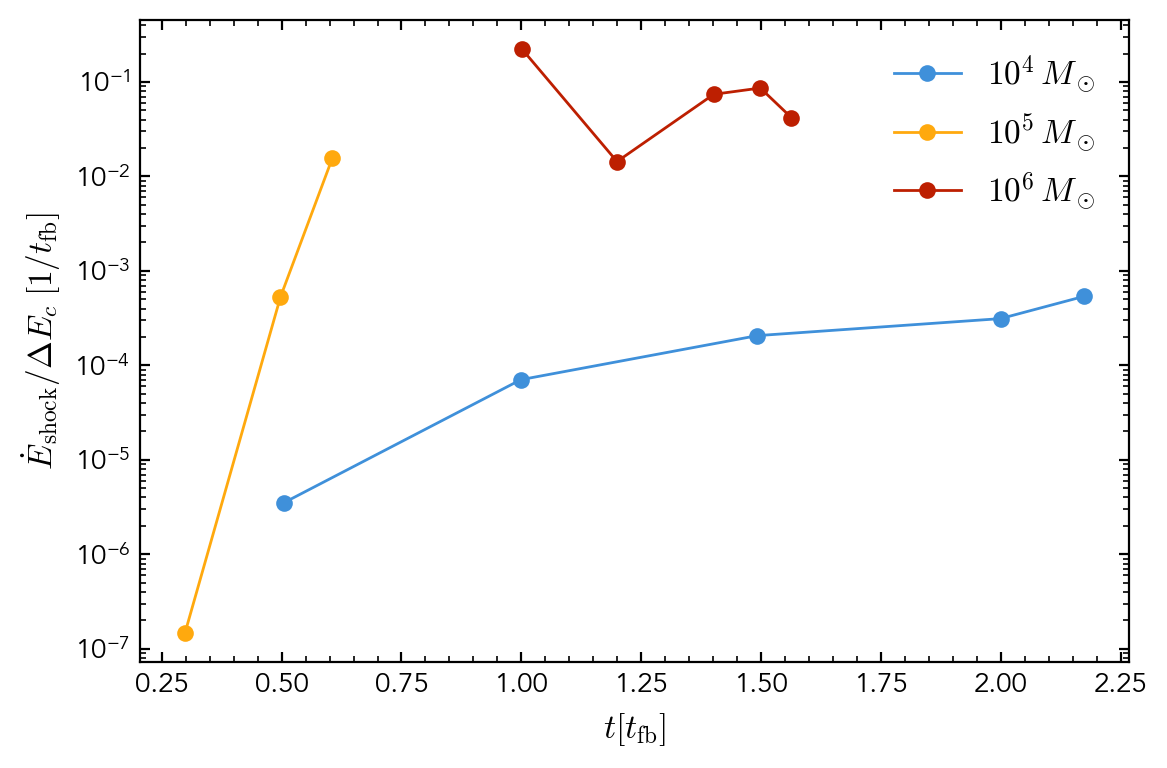

In [4]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
for run in RUNS:
    rows = [row for row in summaries if row['run'] == run]
    cfg = TDE[run]
    Ediss_Deltas = [row['Ediss_erg_s'] * cfg['t_fb_s'] / cfg['Delta_erg'] for row in rows]
    ax.plot([row['time_tfb'] for row in rows], Ediss_Deltas,
            marker='o', color=RUN_COLORS[run], label=RUN_LABELS[run])
ax.set(xlabel=r'$t[t_{\rm fb}]$', ylabel=r'$\dot E_{\rm shock}/\Delta E_c\;[1/t_{\rm fb}]$', yscale='log')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'shockfinder-Ediss-t.png', bbox_inches='tight')
plt.show()

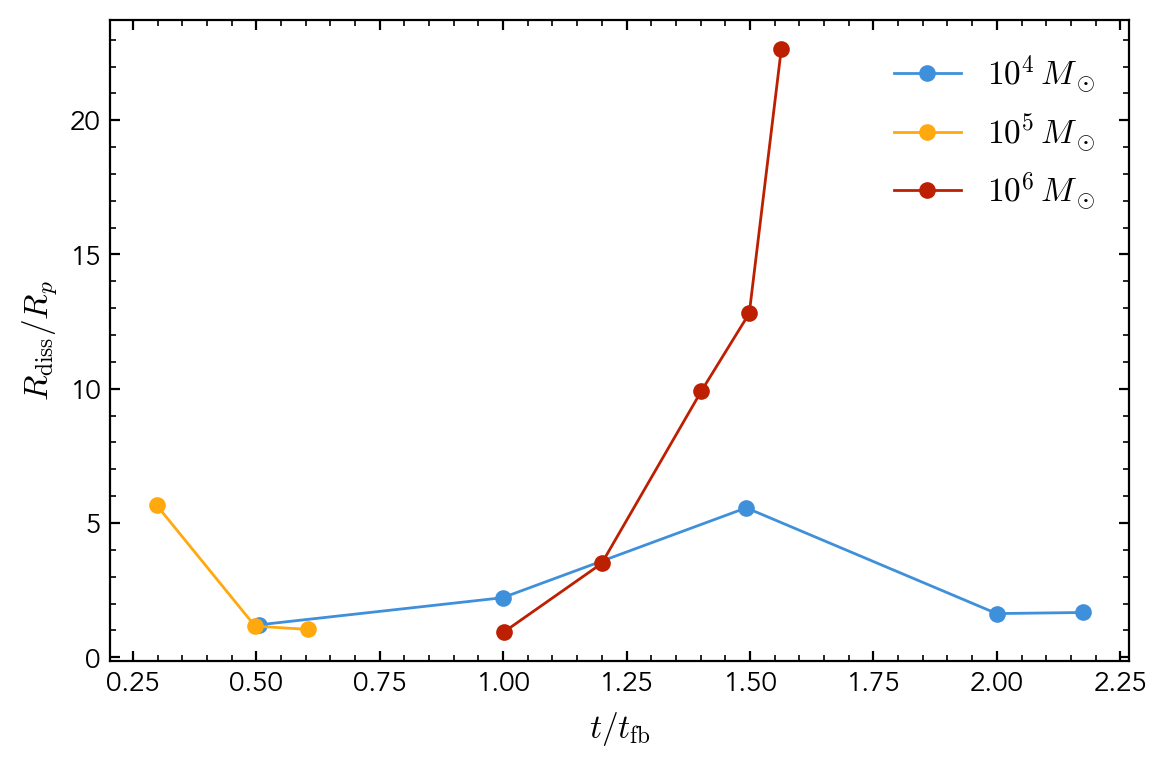

In [5]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
for run in RUNS:
    rows = [row for row in summaries if row['run'] == run]
    rp = TDE[run]['r_p']
    ax.plot([row['time_tfb'] for row in rows], [row['Rdiss_Rsun'] / rp for row in rows],
            marker='o', color=RUN_COLORS[run], label=RUN_LABELS[run])
ax.set(xlabel=r'$t/t_{\rm fb}$', ylabel=r'$R_{\rm diss}/R_p$')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'shockfinder-Rdiss-t.png', bbox_inches='tight')
plt.show()

In [6]:
def plot_radial_distribution(run):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
    rows = [row for row in summaries if row['run'] == run]
    cfg = TDE[run]
    edges = np.geomspace(0.6 * cfg['r_p'], 4 * cfg['r_a'], 80)
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(rows)))
    for row, color in zip(rows, colors):
        with np.load(row['per_cell_path']) as cells:
            radial_power, _ = np.histogram(
                cells['radius_Rsun'], bins=edges, weights=cells['shock_power_erg_s']
            )
        centers = np.sqrt(edges[:-1] * edges[1:])
        dEdiss_dr = radial_power / np.diff(edges)
        label = ('last ' if row['is_last'] else '') + rf"$t={row['time_tfb']:.2f}\,t_{{\rm fb}}$"
        ax.plot(centers, np.where(dEdiss_dr > 0, dEdiss_dr, np.nan), color=color, label=label)
    ax.axvline(cfg['r_p'], color='0.5', linestyle='--', linewidth=1)
    ax.axvline(cfg['r_a'], color='0.5', linestyle=':', linewidth=1)
    ax.set(xscale='log', yscale='log', xlabel=r'$r\;[R_\odot]$',
           ylabel=r'$d\dot E_{\rm shock}/dr\;[\mathrm{erg\,s^{-1}}\,R_\odot^{-1}]$',
           title=RUN_LABELS[run])
    ax.legend(fontsize=7)
    fig.tight_layout()
    fig.savefig(FIGURE_ROOT / f'shockfinder-Ediss-r-{run}.png', bbox_inches='tight')
    plt.show()

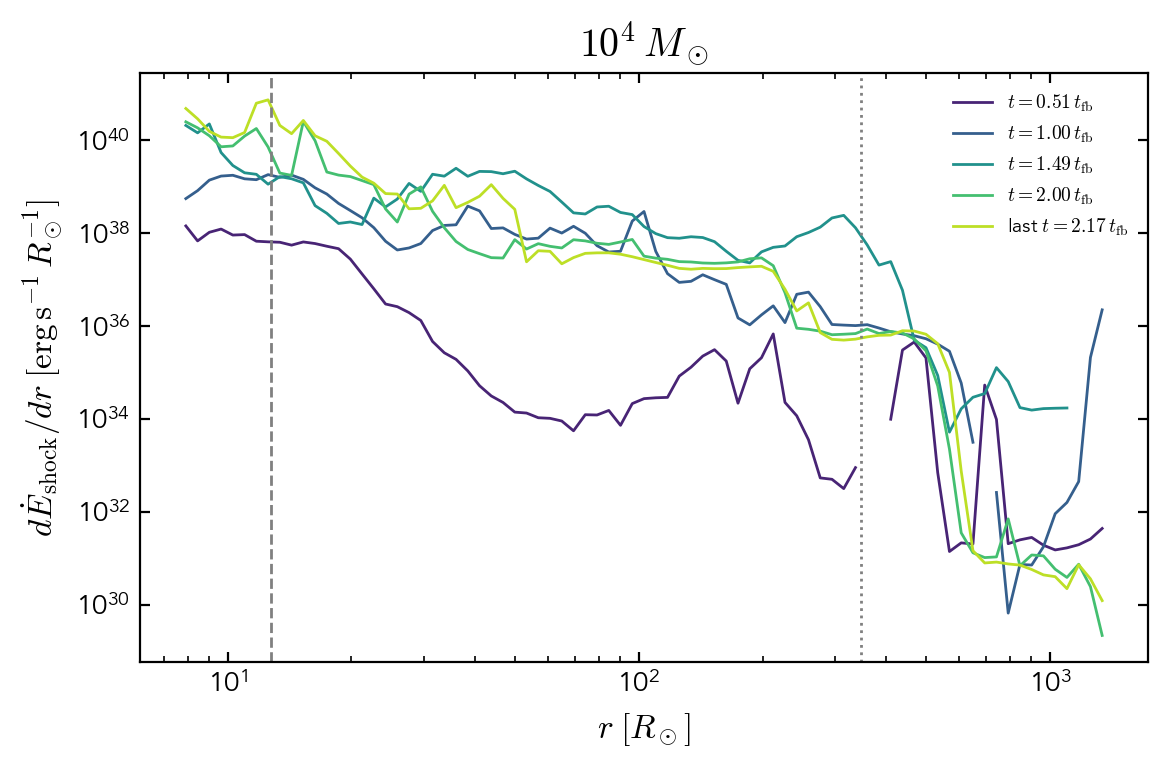

In [7]:
plot_radial_distribution('1e4')

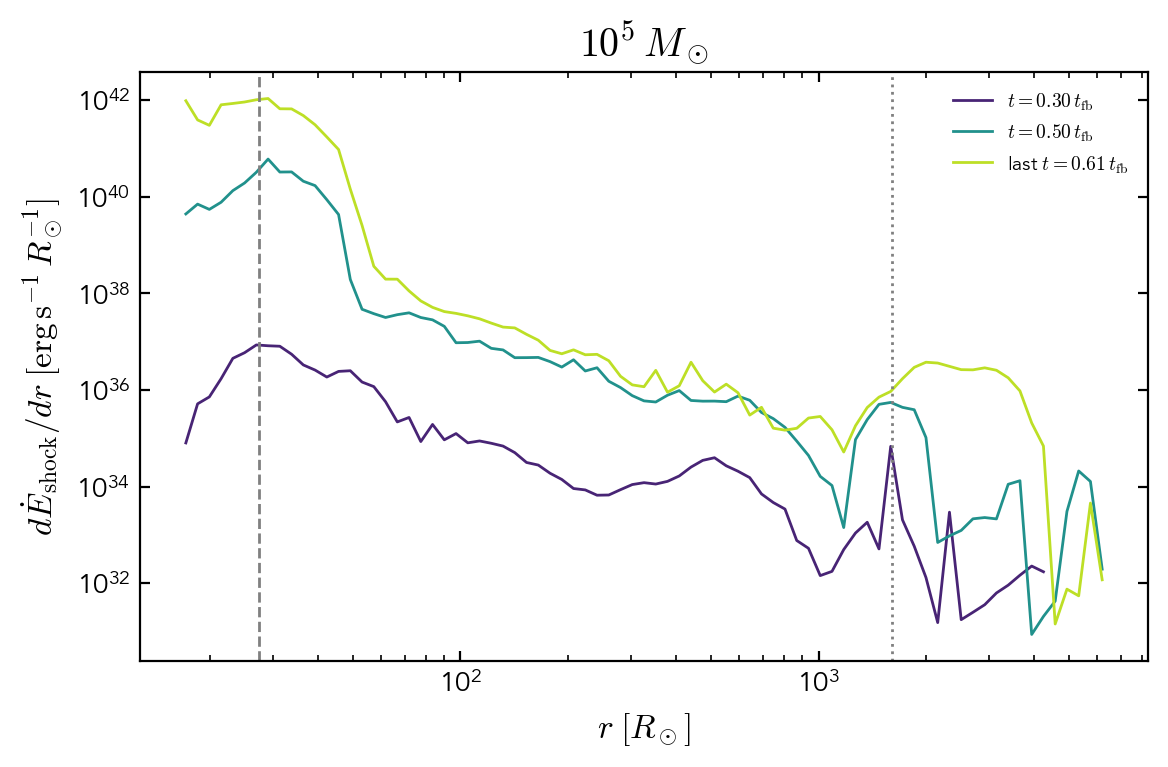

In [8]:
plot_radial_distribution('1e5')

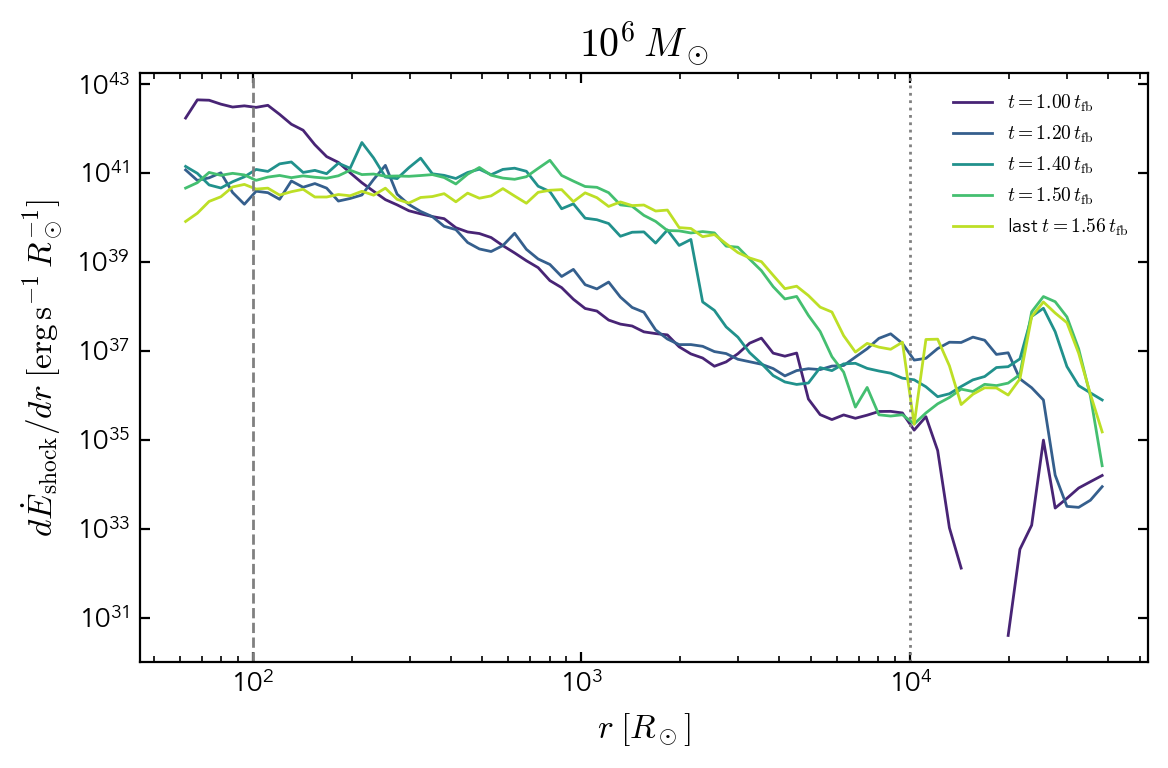

In [9]:
plot_radial_distribution('1e6')